In [1]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt


In [2]:
# import rainyseason as rs
from datetime import timedelta, date

In [3]:
#=======================================================================================
def dates_daily(y0,m0,d0,mtot,noleap):
    """
    Function that calculates arrays of dates (hour, day,month, year)

    Imput:
       y0:     initial year [integer]
       m0:     initial month [integer]
       d0:     initial day [integer]
       mtot:   total number of elements in the time series [integer]
       noleap: flag to indicate whether or not leap years should be considered.
               noleap = 0 --> time searies contain Feb 29
               noleap = 1 --> time series does not contain Feb 29
    Output:
       day:    array with values of days
       month:  array with values of months
       year:   array with values of years
    Example:
    --------
      >>> day,month,year=dates_daily(1980,1,1,365,0)
    """
    day=np.zeros((mtot))
    month=np.zeros((mtot))
    year=np.zeros((mtot))
    start_date=date(y0,m0,d0)
    deltad = timedelta(days=1)
    single_date=start_date
    dt=0
    while dt < mtot:
          day[dt]=single_date.day
          month[dt]=single_date.month
          year[dt]=single_date.year
          if noleap == 0:
             single_date=single_date+deltad
          if noleap == 1:
             if year[dt] % 4 != 0:
                single_date=single_date+deltad
             if year[dt] % 4 == 0:
                if year[dt] % 100 != 0:
                   if month[dt] != 2:
                      single_date=single_date+deltad
                   if month[dt] == 2:
                      if day[dt] < 28:
                         single_date=single_date+deltad
                      if day[dt] == 28:
                         single_date=single_date+2*deltad
                if (year[dt] % 100 == 0) & (year[dt] % 400 != 0):
                   single_date=single_date+deltad
                if year[dt] % 400 == 0:
                   if month[dt] != 2:
                      single_date=single_date+deltad
                   if month[dt] == 2:
                      if day[dt] < 28:
                         single_date=single_date+deltad
                      if day[dt] == 28:
                         single_date=single_date+2*deltad
          dt=dt+1
    return day, month, year


**Step 1 — Prepare the precipitation array**

The script expects a numpy array `prec` of shape `(ntot, nlat, nlon)` in **mm/day**, with no leap days (Feb 29 is removed by averaging with Feb 28). Your `da` is in kg m⁻² s⁻¹, so you need to multiply by 86400. Since CESM2-WACCM uses a NoLeap calendar, those Feb 29s don't exist anyway — but other models on standard calendars will need stripping.

---

**Step 2 — Build date arrays**

The script calls its own `dates_daily()` to get `day`, `month`, `year` arrays of length `ntot`, then computes `jday` (day-of-year) for every timestep. You'll need to extract these from your xarray time coordinate instead, since your calendars vary by model.

---

**Step 3 — Compute the mean annual cycle and smooth it with 3 harmonics**

For each grid point it computes the climatological mean daily cycle (`cycle`, shape `(365, nlat, nlon)`), then fits 3 Fourier harmonics to smooth it (`smoothed`). It also stores just the first harmonic (`harmonic1`) — this is used to find the seasonal minimum, which defines `startwet`: the julian day that is the *starting point* for searching onset/demise.

---

**Step 4 — Mask out grid points with zero or multiple rainy seasons**

It uses the explained variance of harmonics 1, 2, 3. If `harm2 >= harm1` or `harm3 >= harm1`, the grid point is masked — it either has no clear annual cycle or has more than one rainy season per year.

---

**Step 5 — Compute the anomaly `ap`**

For each grid point: `ap = prec[:,it,jt] - rm[it,jt]` where `rm` is the long-term daily mean. This is the **precipitation anomaly from the annual mean** (not from the smoothed cycle — note this carefully).

---

**Step 6 — Run onset (first pass: Liebmann & Marengo 2001)**

Calls `rainyseason_onset()` with the anomaly `ap`, date arrays, and `sdate=startwet[it,jt]`. This returns `wjd` (onset julian day), `wd`, `wm`, `wy` (day/month/year of onset) per year, plus `wsc` (the cumulative anomaly curve segment). Outliers are removed using circular statistics + 1.5×IQR.

---

**Step 7 — Run onset (second pass: Bombardi et al. 2017)**

For any year where onset was not found (i.e. `wjd==0`), it calls `rainyseason_B17_onset()` as a fallback, then applies a stricter 3×IQR outlier filter.

---

**Step 8 — Run demise (same two-pass structure)**

Exactly mirroring steps 6–7 but using `rainyseason_demise()` and `rainyseason_B17_demise()`. Note: demise is computed *retrospectively* (looking backward from `startwet`), so the year-indexing is shifted at the end.

---

**Step 9 — Compute duration and accumulated precipitation**

For each year and grid point it figures out whether onset/demise span the same year or straddle a year boundary, then sums `prec[beg:ned]` and counts days. Four combinations are handled.

---

**Step 10 — Save to NetCDF**

Saves 8 separate NetCDF files (onset DOY/day/month/year, demise DOY/day/month/year, totwet, totdry, durwet, durdry). Note it saves `[0:nyrs-2]` — the last 2 years are dropped because demise of the final year's rainy season may fall outside the data period.

---

**The key things your adapter needs to handle:**

1. **Unit conversion** — ×86400
2. **Feb 29 removal** — only for standard-calendar models (not CESM2-WACCM NoLeap)
3. **Date array extraction** — from cftime or numpy datetime64 into plain numpy `day/month/year/jday` arrays
4. **Pass the right `yr0`** — the script uses it for index arithmetic (`(year - yr0) * tot + jday - 1`), so it must match the actual first year in `year[]`
5. **Output filenames** — encode model name and experiment instead of `CPC_UNI`

---

Order:

1. Unit conversion + Feb 29 removal
2. Date array extraction (handling both calendar types)
3. The main grid-point loop calling the Bombardi functions
4. Duration/accumulation block (this is the trickiest)
5. NetCDF output

In [4]:
import xarray as xr
from pathlib import Path

import sys
import os
analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

In [5]:
# =========================
# User-defined metadata
# =========================

varname = "pr"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")

In [6]:
#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


In [7]:
#Experiment details
EXPERIMENTS = {
    "HIST":     {"project": "CMIP",        "scenario": "historical", "color": "black"},
    # "SSP245":   {"project": "ScenarioMIP", "scenario": "ssp245"},
    # "SSP585":   {"project": "ScenarioMIP", "scenario": "ssp585"},
    # "G6solar":  {"project": "GeoMIP",      "scenario": "G6solar"},
    # "G6sulfur": {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

In [8]:
# ── Step 1: Select only UKESM1-0-LL / HIST for now ──────────────────────────

model_name = "UKESM1-0-LL"
exp        = "HIST"

model_meta = MODELS[model_name]
meta       = EXPERIMENTS[exp]
ensemble   = model_meta["ensemble"]

base = (
    CEDA_BASE
    / meta["project"]
    / model_meta["institution"]
    / model_name
    / meta["scenario"]
    / ensemble
    / "day"
    / varname
    / model_meta["grid"]
    / "latest"
)

print(f"Reading {model_name} {exp}")
ds = mf.open_files(str(base))
da = mf.read_var(ds, varname)

# ── Step 2: Time slice ───────────────────────────────────────────────────────

da = da.sel(time=slice("2001-01-01", "2010-12")).load()

# ── Step 3: Unit conversion  kg m⁻² s⁻¹  →  mm/day ─────────────────────────

da_mm = da * 86400.0
da_mm.attrs["units"] = "mm/day"

# ── Step 4: Ensure dimension order is (time, lat, lon) ──────────────────────

da_mm = da_mm.transpose("time", "lat", "lon")

# ── Step 5: Extract numpy array → this is Bombardi's "prec" ─────────────────

prec = da_mm.values                   # shape (ntot, nlat, nlon)

# ── Step 6: Scalar metadata Bombardi needs ───────────────────────────────────

ntot = prec.shape[0]                  # total number of time steps
nlat = prec.shape[1]
nlon = prec.shape[2]
lats = da_mm.lat.values
lons = da_mm.lon.values
missval = -999.0
tot = 365.0                           # days per year (no-leap / CMIP standard)

# ── Sanity check ─────────────────────────────────────────────────────────────

print(f"prec shape : {prec.shape}")          # expect (3650, nlat, nlon)
print(f"ntot={ntot}, nlat={nlat}, nlon={nlon}")
print(f"pr range   : {prec.min():.4f} – {prec.max():.4f} mm/day")
print(f"lats       : {lats[0]:.2f} → {lats[-1]:.2f}")
print(f"lons       : {lons[0]:.2f} → {lons[-1]:.2f}")

Reading UKESM1-0-LL HIST
prec shape : (3600, 144, 192)
ntot=3600, nlat=144, nlon=192
pr range   : 0.0000 – 1076.3290 mm/day
lats       : -89.38 → 89.38
lons       : 0.94 → 359.06


In [9]:
#------------------------------------------------------------------------
# Creating vectors of dates
#------------------------------------------------------------------------                 

import numpy as np
import cftime

# ── Step 2: Build date arrays from xarray time coordinate ───────────────────
# We do NOT use Bombardi's dates_daily() — it uses Python's datetime.date
# which doesn't support 360-day calendars. Extract directly from cftime.

time_values = da_mm.time.values   # array of cftime objects

year  = np.array([t.year                  for t in time_values], dtype=int)
month = np.array([t.month                 for t in time_values], dtype=int)
day   = np.array([t.day                   for t in time_values], dtype=int)
jday  = np.array([t.timetuple().tm_yday   for t in time_values], dtype=int)

# ── Update tot to match the actual calendar ──────────────────────────────────

tot  = float(int(ntot / len(np.unique(year))))   # 360 for UKESM, 365 for others
yr0  = int(year[0])                              # first year in the slice

# ── Sanity check ─────────────────────────────────────────────────────────────

print(f"Calendar    : {type(time_values[0]).__name__}")
print(f"tot         : {tot}")
print(f"yr0         : {yr0}")
print(f"year range  : {year[0]} – {year[-1]}")
print(f"jday range  : {jday[0]} – {jday[-1]}")
print(f"First 5 dates: ", [(day[i], month[i], year[i], jday[i]) for i in range(5)])
print(f"Last  5 dates: ", [(day[i], month[i], year[i], jday[i]) for i in range(-5,0)])

Calendar    : Datetime360Day
tot         : 360.0
yr0         : 2001
year range  : 2001 – 2010
jday range  : 1 – 360
First 5 dates:  [(np.int64(1), np.int64(1), np.int64(2001), np.int64(1)), (np.int64(2), np.int64(1), np.int64(2001), np.int64(2)), (np.int64(3), np.int64(1), np.int64(2001), np.int64(3)), (np.int64(4), np.int64(1), np.int64(2001), np.int64(4)), (np.int64(5), np.int64(1), np.int64(2001), np.int64(5))]
Last  5 dates:  [(np.int64(26), np.int64(12), np.int64(2010), np.int64(356)), (np.int64(27), np.int64(12), np.int64(2010), np.int64(357)), (np.int64(28), np.int64(12), np.int64(2010), np.int64(358)), (np.int64(29), np.int64(12), np.int64(2010), np.int64(359)), (np.int64(30), np.int64(12), np.int64(2010), np.int64(360))]


In [10]:
import math

# ── Step 3a: Daily annual mean (rm) ─────────────────────────────────────────
# rm[it,jt] = long-term mean daily precipitation at each grid point

prec[prec < 0.] = missval          # safety: flag negatives as missing

mask = np.zeros((nlat, nlon))
thres = ntot - 0.01 * 25. * ntot   # dper = 25%

for it in range(nlat):
    for jt in range(nlon):
        id = np.where(prec[:, it, jt] != missval)
        if len(id[0]) >= thres:
            mask[it, jt] = 1.

rm = np.zeros((nlat, nlon))
for it in range(nlat):
    for jt in range(nlon):
        if mask[it, jt] == 1.:
            tmp = prec[:, it, jt]
            id  = np.where(tmp >= 0.)
            if len(id[0]) > 1:
                rm[it, jt] = np.mean(tmp[id[0]])

print(f"rm range: {rm.min():.4f} – {rm.max():.4f} mm/day")

# ── Step 3b: Mean annual cycle ───────────────────────────────────────────────
# cycle[doy, it, jt] = mean precip on each day-of-year

tot_int = int(tot)
cycle = np.zeros((tot_int, nlat, nlon))

for tt in range(tot_int):
    id = np.where(jday[:] == tt + 1)     # days matching this DOY
    for it in range(nlat):
        for jt in range(nlon):
            if mask[it, jt] == 1.:
                tmp  = prec[id[0], it, jt]
                id2  = np.where(tmp >= 0.)
                if len(id2[0]) > 1:
                    cycle[tt, it, jt] = np.mean(tmp[id2[0]])

print("Mean annual cycle calculated.")

# ── Step 3c: Harmonic smoothing (first 3 harmonics) ─────────────────────────

def Harmonics(coefa, coefb, hvar, tseries, nmodes, missval):
    mtot  = len(tseries)
    time  = np.arange(1, mtot + 1, 1.)
    tdata = tseries.copy()
    tdata[tseries == missval] = 0.
    svar  = sum((tdata - np.mean(tdata))**2) / (mtot - 1)
    nm    = nmodes
    if 2 * nm > mtot:
        nm = mtot // 2
    coefa = np.zeros(nm)
    coefb = np.zeros(nm)
    hvar  = np.zeros(nm)
    for tt in range(nm):
        Ak = np.sum(tdata * np.cos(2. * math.pi * (tt+1) * time / float(mtot)))
        Bk = np.sum(tdata * np.sin(2. * math.pi * (tt+1) * time / float(mtot)))
        coefa[tt] = Ak * 2. / float(mtot)
        coefb[tt] = Bk * 2. / float(mtot)
        hvar[tt]  = mtot * (coefa[tt]**2 + coefb[tt]**2) / (2. * (mtot-1) * svar)
    return coefa, coefb, hvar

time_arr = np.arange(1, tot_int + 1, 1.)
harm1     = np.zeros((nlat, nlon))
harm2     = np.zeros((nlat, nlon))
harm3     = np.zeros((nlat, nlon))
harmonic1 = np.zeros((tot_int, nlat, nlon))
smoothed  = np.zeros((tot_int, nlat, nlon))

for it in range(nlat):
    for jt in range(nlon):
        if mask[it, jt] == 1.:
            coefa  = np.zeros(3)
            coefb  = np.zeros(3)
            hvar   = np.zeros(3)
            tseries = cycle[:, it, jt]
            coefa, coefb, hvar = Harmonics(coefa, coefb, hvar, tseries, 3, missval)
            harm1[it, jt] = hvar[0]
            harm2[it, jt] = hvar[1]
            harm3[it, jt] = hvar[2]
            # First harmonic only (used to find startwet)
            harmonic1[:, it, jt] = rm[it, jt]
            harmonic1[:, it, jt] = (harmonic1[:, it, jt]
                + coefa[0] * np.cos(2. * math.pi * time_arr / float(tot_int))
                + coefb[0] * np.sin(2. * math.pi * time_arr / float(tot_int)))
            # Full 3-harmonic smoothed cycle
            smoothed[:, it, jt] = np.mean(cycle[:, it, jt])
            for pp in range(3):
                smoothed[:, it, jt] = (smoothed[:, it, jt]
                    + coefa[pp] * np.cos(2. * math.pi * time_arr * (pp+1) / float(tot_int))
                    + coefb[pp] * np.sin(2. * math.pi * time_arr * (pp+1) / float(tot_int)))

print("Mean annual cycle smoothed.")

# ── Step 3d: Mask grid points with zero or multiple rainy seasons ────────────

id = np.where(harm2 >= harm1);  mask[id] = 0.;  rm[id] = 0.
id = np.where(harm3 >= harm1);  mask[id] = 0.;  rm[id] = 0.

print(f"Active grid points after harmonic masking: {int(mask.sum())} / {nlat*nlon}")

# ── Step 3e: Find startwet — DOY of the annual precipitation minimum ─────────
# This is the starting point for searching onset/demise at each grid point

startwet = np.zeros((nlat, nlon))
for it in range(nlat):
    for jt in range(nlon):
        if mask[it, jt] == 1.:
            id = np.where(harmonic1[:, it, jt] == harmonic1[:, it, jt].min())
            startwet[it, jt] = jday[id[0][0]]   # scalar DOY

print(f"startwet range: {startwet[startwet>0].min():.0f} – {startwet[startwet>0].max():.0f} DOY")
print("Step 3 complete.")

rm range: 0.0078 – 23.1248 mm/day
Mean annual cycle calculated.
Mean annual cycle smoothed.
Active grid points after harmonic masking: 23412 / 27648
startwet range: 1 – 360 DOY
Step 3 complete.


In [11]:
import sys
sys.path.append('./rainyseason_functions')   # ← edit to where the 4 scripts live

from rainyseason_onset import rainyseason_onset
from rainyseason_B17_onset import rainyseason_B17_onset
from rainyseason_demise import rainyseason_demise
from rainyseason_B17_demise import rainyseason_B17_demise

# ── Step 4a: Initialise output arrays ────────────────────────────────────────

nyrs   = int(year.max() - year.min()) + 1   # 10
tot_int = int(tot)                           # 360
npass  = 50

ap = np.zeros((ntot))

onset_jday  = np.zeros((nyrs, nlat, nlon))
onset_day   = np.zeros((nyrs, nlat, nlon))
onset_month = np.zeros((nyrs, nlat, nlon))
onset_year  = np.zeros((nyrs, nlat, nlon))

demise_jday  = np.zeros((nyrs, nlat, nlon))
demise_day   = np.zeros((nyrs, nlat, nlon))
demise_month = np.zeros((nyrs, nlat, nlon))
demise_year  = np.zeros((nyrs, nlat, nlon))

durwet  = np.zeros((nyrs, nlat, nlon))
durdry  = np.zeros((nyrs, nlat, nlon))
totwet  = np.zeros((nyrs, nlat, nlon))
totdry  = np.zeros((nyrs, nlat, nlon))

wjd = np.zeros((nyrs));  wd = np.zeros((nyrs))
wm  = np.zeros((nyrs));  wy = np.zeros((nyrs))
wsc = np.zeros((nyrs, tot_int // 2))

djd = np.zeros((nyrs));  dd = np.zeros((nyrs))
dm  = np.zeros((nyrs));  dy = np.zeros((nyrs))
dsc = np.zeros((nyrs, tot_int // 2))

prec[prec < 0.] = 0.   # VERY IMPORTANT — as in Bombardi

# ── Step 4b: Main grid-point loop ────────────────────────────────────────────

print("Calculating onset and demise of the rainy season...")

for it in range(nlat):
    print(f"  lat {it+1}/{nlat}")
    for jt in range(nlon):
        if rm[it, jt] > 0.:
            sdate = startwet[it, jt]
            ap[:] = prec[:, it, jt] - rm[it, jt]

            # ── ONSET first pass (Liebmann & Marengo 2001) ───────────────
            wjd[:]=0.; wd[:]=0.; wm[:]=0.; wy[:]=0.; wsc[:]=0.
            wjd[:],wd[:],wm[:],wy[:],wsc[:,:] = rainyseason_onset(
                nyrs, tot_int, jday, day, month, year,
                sdate, ap, wjd, wd, wm, wy, wsc)

            # Quality control: circular stats + 1.5×IQR outlier removal
            miss = np.where(wjd[:] == 0.)
            id   = np.where(wjd[:] != 0.)
            if len(id[0]) > 0:
                tmpx = np.cos(wjd * math.pi / 183.)
                tmpy = np.sin(wjd * math.pi / 183.)
                med  = math.atan2(np.median(tmpy[id]), np.median(tmpx[id])) * 183. / math.pi
                if med < 0.: med += tot
                tmpc = wjd[:] - med
                if len(miss[0]) > 0: tmpc[miss] = 0.
                pos = np.where(tmpc >  tot * 0.5); tmpc[pos] -= tot
                neg = np.where(tmpc < -tot * 0.5); tmpc[neg] += tot
                iqr  = np.percentile(tmpc[id], 75) - np.percentile(tmpc[id], 25)
                outl = np.where(np.abs(tmpc) > iqr * 1.5)
                if len(outl[0]) > 0:
                    wjd[outl]=0.; wd[outl]=0.; wm[outl]=0.; wy[outl]=0.
                onset_jday[:,it,jt]  = wjd
                onset_day[:,it,jt]   = wd
                onset_month[:,it,jt] = wm
                onset_year[:,it,jt]  = wy

                # ── ONSET second pass (Bombardi et al. 2017) ─────────────
                # ── ONSET second pass (corrected) ────────────────────────────────────────────
                outl = np.where(wjd == 0.)
                if len(outl[0]) > 0:
                    wjd[:]=0.; wd[:]=0.; wm[:]=0.; wy[:]=0.
                    
                    # Build the start-date sub-arrays for this grid point's sdate
                    sid    = np.where(jday == sdate)[0]
                    sjday_ = jday[sid];   sday_  = day[sid]
                    smonth_= month[sid];  syear_ = year[sid]
                    
                    wjd[:],wd[:],wm[:],wy[:] = rainyseason_B17_onset(
                        nyrs, tot_int,                              # ← int, not float
                        jday, day, month, year,
                        sdate, ap, npass,
                        sjday_, sday_, smonth_, syear_)             # ← 4 extra arrays
                    onset_jday[outl,it,jt]  = wjd[outl]
                    onset_day[outl,it,jt]   = wd[outl]
                    onset_month[outl,it,jt] = wm[outl]
                    onset_year[outl,it,jt]  = wy[outl]
                    # Second QC: circular stats + 3×IQR
                    wjd[:] = onset_jday[:,it,jt]
                    miss   = np.where(wjd == 0.)
                    id     = np.where(wjd != 0.)
                    if len(id[0]) > 0:
                        tmpx = np.cos(wjd * math.pi / 183.)
                        tmpy = np.sin(wjd * math.pi / 183.)
                        med  = math.atan2(np.median(tmpy[id]), np.median(tmpx[id])) * 183. / math.pi
                        if med < 0.: med += tot
                        tmpc = wjd[:] - med
                        if len(miss[0]) > 0: tmpc[miss] = 0.
                        pos = np.where(tmpc >  tot * 0.5); tmpc[pos] -= tot
                        neg = np.where(tmpc < -tot * 0.5); tmpc[neg] += tot
                        iqr  = np.percentile(tmpc[id], 75) - np.percentile(tmpc[id], 25)
                        outl = np.where(np.abs(tmpc) > iqr * 3.)
                        if len(outl[0]) > 0:
                            onset_jday[outl,it,jt]=0.; onset_day[outl,it,jt]=0.
                            onset_month[outl,it,jt]=0.; onset_year[outl,it,jt]=0.

            # ── DEMISE first pass (Liebmann & Marengo 2001) ──────────────
            djd[:]=0.; dd[:]=0.; dm[:]=0.; dy[:]=0.; dsc[:]=0.
            djd[:],dd[:],dm[:],dy[:],dsc[:,:] = rainyseason_demise(
                nyrs, tot_int, jday, day, month, year,
                sdate, ap, djd, dd, dm, dy, dsc)

            # Quality control: circular stats + 1.5×IQR
            miss = np.where(djd == 0.)
            id   = np.where(djd != 0.)
            if len(id[0]) > 0:
                tmpx = np.cos(djd * math.pi / 183.)
                tmpy = np.sin(djd * math.pi / 183.)
                med  = math.atan2(np.median(tmpy[id]), np.median(tmpx[id])) * 183. / math.pi
                if med < 0.: med += tot
                tmpc = djd[:] - med
                if len(miss[0]) > 0: tmpc[miss] = 0.
                pos = np.where(tmpc >  tot * 0.5); tmpc[pos] -= tot
                neg = np.where(tmpc < -tot * 0.5); tmpc[neg] += tot
                iqr  = np.percentile(tmpc[id], 75) - np.percentile(tmpc[id], 25)
                outl = np.where(np.abs(tmpc) > iqr * 1.5)
                if len(outl[0]) > 0:
                    djd[outl]=0.; dd[outl]=0.; dm[outl]=0.; dy[outl]=0.
                demise_jday[:,it,jt]  = djd
                demise_day[:,it,jt]   = dd
                demise_month[:,it,jt] = dm
                demise_year[:,it,jt]  = dy

                # ── DEMISE second pass (Bombardi et al. 2017) ────────────
                # ── DEMISE second pass (corrected) ───────────────────────────────────────────
                outl = np.where(djd == 0.)
                if len(outl[0]) > 0:
                    djd[:]=0.; dd[:]=0.; dm[:]=0.; dy[:]=0.
                    
                    sid    = np.where(jday == sdate)[0]
                    sjday_ = jday[sid];   sday_  = day[sid]
                    smonth_= month[sid];  syear_ = year[sid]
                    
                    djd[:],dd[:],dm[:],dy[:] = rainyseason_B17_demise(
                        nyrs, tot_int,                              # ← int, not float
                        jday, day, month, year,
                        sdate, ap, npass,
                        sjday_, sday_, smonth_, syear_)             # ← 4 extra arrays
                    demise_jday[outl,it,jt]  = djd[outl]
                    demise_day[outl,it,jt]   = dd[outl]
                    demise_month[outl,it,jt] = dm[outl]
                    demise_year[outl,it,jt]  = dy[outl]
                    # Second QC: circular stats + 3×IQR
                    djd[:] = demise_jday[:,it,jt]
                    miss   = np.where(djd == 0.)
                    id     = np.where(djd != 0.)
                    if len(id[0]) > 0:
                        tmpx = np.cos(djd * math.pi / 183.)
                        tmpy = np.sin(djd * math.pi / 183.)
                        med  = math.atan2(np.median(tmpy[id]), np.median(tmpx[id])) * 183. / math.pi
                        if med < 0.: med += tot
                        tmpc = djd[:] - med
                        if len(miss[0]) > 0: tmpc[miss] = 0.
                        pos = np.where(tmpc >  tot * 0.5); tmpc[pos] -= tot
                        neg = np.where(tmpc < -tot * 0.5); tmpc[neg] += tot
                        iqr  = np.percentile(tmpc[id], 75) - np.percentile(tmpc[id], 25)
                        outl = np.where(np.abs(tmpc) > iqr * 3.)
                        if len(outl[0]) > 0:
                            demise_jday[outl,it,jt]=0.; demise_day[outl,it,jt]=0.
                            demise_month[outl,it,jt]=0.; demise_year[outl,it,jt]=0.

            # ── Mask grid points where > 33% of years are missing ────────
            id = np.where(onset_jday[:,it,jt] == 0.)
            if len(id[0]) / float(nyrs) > 0.33:
                rm[it,jt]=0.
                onset_jday[:,it,jt]=0.; onset_day[:,it,jt]=0.
                onset_month[:,it,jt]=0.; onset_year[:,it,jt]=0.

            id = np.where(demise_jday[:,it,jt] == 0.)
            if len(id[0]) / float(nyrs) > 0.33:
                rm[it,jt]=0.
                demise_jday[:,it,jt]=0.; demise_day[:,it,jt]=0.
                demise_month[:,it,jt]=0.; demise_year[:,it,jt]=0.

            # ── Rearrange demise years (retrospective correction) ────────
            if demise_year[1,it,jt] == float(yr0) or demise_year[2,it,jt] == float(yr0+1):
                demise_year[0:nyrs-1,it,jt]  = demise_year[1:nyrs,it,jt];  demise_year[nyrs-1,it,jt]=0.
                demise_month[0:nyrs-1,it,jt] = demise_month[1:nyrs,it,jt]; demise_month[nyrs-1,it,jt]=0.
                demise_day[0:nyrs-1,it,jt]   = demise_day[1:nyrs,it,jt];   demise_day[nyrs-1,it,jt]=0.
                demise_jday[0:nyrs-1,it,jt]  = demise_jday[1:nyrs,it,jt];  demise_jday[nyrs-1,it,jt]=0.

print("Onset and demise calculated.")

Calculating onset and demise of the rainy season...
  lat 1/144
  lat 2/144
  lat 3/144
  lat 4/144
  lat 5/144
  lat 6/144
  lat 7/144
  lat 8/144
  lat 9/144
  lat 10/144
  lat 11/144
  lat 12/144
  lat 13/144
  lat 14/144
  lat 15/144
  lat 16/144
  lat 17/144
  lat 18/144
  lat 19/144
  lat 20/144
  lat 21/144
  lat 22/144
  lat 23/144
  lat 24/144
  lat 25/144
  lat 26/144
  lat 27/144
  lat 28/144
  lat 29/144
  lat 30/144
  lat 31/144
  lat 32/144
  lat 33/144
  lat 34/144
  lat 35/144
  lat 36/144
  lat 37/144
  lat 38/144
  lat 39/144
  lat 40/144
  lat 41/144
  lat 42/144
  lat 43/144
  lat 44/144
  lat 45/144
  lat 46/144
  lat 47/144
  lat 48/144
  lat 49/144
  lat 50/144
  lat 51/144
  lat 52/144
  lat 53/144
  lat 54/144
  lat 55/144
  lat 56/144
  lat 57/144
  lat 58/144
  lat 59/144
  lat 60/144
  lat 61/144
  lat 62/144
  lat 63/144
  lat 64/144
  lat 65/144
  lat 66/144
  lat 67/144
  lat 68/144
  lat 69/144
  lat 70/144
  lat 71/144
  lat 72/144
  lat 73/144
  lat 74

In [12]:
# ── Reinitialise output arrays (clean slate) ─────────────────────────────────
durwet = np.zeros((nyrs, nlat, nlon))
durdry = np.zeros((nyrs, nlat, nlon))
totwet = np.zeros((nyrs, nlat, nlon))
totdry = np.zeros((nyrs, nlat, nlon))

# ── Restore onset/demise to zeros-for-missing (undo the -999 replacement) ────
# _ds = xr.open_dataset(outfile)

# def restore(arr):
#     return np.where(arr == missval, 0., arr)

# def pad(arr):
#     out = np.zeros((nyrs,) + arr.shape[1:])
#     out[:arr.shape[0]] = arr
#     return out

# onset_jday   = pad(restore(_ds["onset_jday"].values))
# onset_year   = pad(restore(_ds["onset_year"].values))
# onset_day    = pad(restore(_ds["onset_day"].values))
# onset_month  = pad(restore(_ds["onset_month"].values))
# demise_jday  = pad(restore(_ds["demise_jday"].values))
# demise_year  = pad(restore(_ds["demise_year"].values))
# demise_day   = pad(restore(_ds["demise_day"].values))
# demise_month = pad(restore(_ds["demise_month"].values))
# _ds.close()

print("Arrays restored. Running duration calculation...")

# ── Step 5a: Duration and accumulated precipitation ──────────────────────────

print("Calculating duration and accumulated precipitation...")

for it in range(nlat):
    for jt in range(nlon):
        for yt in range(nyrs):
            if onset_year[yt,it,jt] == 0. or demise_year[yt,it,jt] == 0.:
                continue

            if demise_year[yt,it,jt] == onset_year[yt,it,jt]:
                if demise_jday[yt,it,jt] < onset_jday[yt,it,jt]:
                    # dry season is within this year
                    beg = int((demise_year[yt,it,jt] - yr0) * tot_int + demise_jday[yt,it,jt] - 1)
                    ned = int((onset_year[yt,it,jt]  - yr0) * tot_int + onset_jday[yt,it,jt]  - 1)
                    if 0 <= beg < ned <= ntot:
                        durdry[yt,it,jt] = float(ned - beg)
                        totdry[yt,it,jt] = np.sum(prec[beg:ned, it, jt])
                    if yt < nyrs - 1 and demise_year[yt+1,it,jt] > 0.:
                        beg = int((onset_year[yt,it,jt]    - yr0) * tot_int + onset_jday[yt,it,jt]    - 1)
                        ned = int((demise_year[yt+1,it,jt] - yr0) * tot_int + demise_jday[yt+1,it,jt] - 1)
                        if 0 <= beg < ned <= ntot:
                            durwet[yt,it,jt] = float(ned - beg)
                            totwet[yt,it,jt] = np.sum(prec[beg:ned, it, jt])

                elif onset_jday[yt,it,jt] < demise_jday[yt,it,jt]:
                    # wet season is within this year
                    beg = int((onset_year[yt,it,jt]  - yr0) * tot_int + onset_jday[yt,it,jt]  - 1)
                    ned = int((demise_year[yt,it,jt]  - yr0) * tot_int + demise_jday[yt,it,jt] - 1)
                    if 0 <= beg < ned <= ntot:
                        durwet[yt,it,jt] = float(ned - beg)
                        totwet[yt,it,jt] = np.sum(prec[beg:ned, it, jt])
                    if yt < nyrs - 1 and onset_year[yt+1,it,jt] > 0.:
                        beg = int((demise_year[yt,it,jt]   - yr0) * tot_int + demise_jday[yt,it,jt]   - 1)
                        ned = int((onset_year[yt+1,it,jt]  - yr0) * tot_int + onset_jday[yt+1,it,jt]  - 1)
                        if 0 <= beg < ned <= ntot:
                            durdry[yt,it,jt] = float(ned - beg)
                            totdry[yt,it,jt] = np.sum(prec[beg:ned, it, jt])

            elif 0. < demise_year[yt,it,jt] < onset_year[yt,it,jt]:
                # onset found in year+1
                beg = int((demise_year[yt,it,jt] - yr0) * tot_int + demise_jday[yt,it,jt] - 1)
                ned = int((onset_year[yt,it,jt]  - yr0) * tot_int + onset_jday[yt,it,jt]  - 1)
                if 0 <= beg < ned <= ntot:
                    durdry[yt,it,jt] = float(ned - beg)
                    totdry[yt,it,jt] = np.sum(prec[beg:ned, it, jt])
                if yt < nyrs - 1 and demise_year[yt+1,it,jt] > 0.:
                    if onset_jday[yt,it,jt] < demise_jday[yt+1,it,jt]:
                        beg = int((onset_year[yt,it,jt]    - yr0) * tot_int + onset_jday[yt,it,jt]    - 1)
                        ned = int((demise_year[yt+1,it,jt] - yr0) * tot_int + demise_jday[yt+1,it,jt] - 1)
                        if 0 <= beg < ned <= ntot:
                            durwet[yt,it,jt] = float(ned - beg)
                            totwet[yt,it,jt] = np.sum(prec[beg:ned, it, jt])

            elif 0. < onset_year[yt,it,jt] < demise_year[yt,it,jt]:
                # demise found in year+1
                beg = int((onset_year[yt,it,jt]  - yr0) * tot_int + onset_jday[yt,it,jt]  - 1)
                ned = int((demise_year[yt,it,jt]  - yr0) * tot_int + demise_jday[yt,it,jt] - 1)
                if 0 <= beg < ned <= ntot:
                    durwet[yt,it,jt] = float(ned - beg)
                    totwet[yt,it,jt] = np.sum(prec[beg:ned, it, jt])
                if yt < nyrs - 1 and onset_year[yt+1,it,jt] > 0.:
                    if demise_jday[yt,it,jt] < onset_jday[yt+1,it,jt]:
                        beg = int((demise_year[yt,it,jt]   - yr0) * tot_int + demise_jday[yt,it,jt]   - 1)
                        ned = int((onset_year[yt+1,it,jt]  - yr0) * tot_int + onset_jday[yt+1,it,jt]  - 1)
                        if 0 <= beg < ned <= ntot:
                            durdry[yt,it,jt] = float(ned - beg)
                            totdry[yt,it,jt] = np.sum(prec[beg:ned, it, jt])

print("Duration and accumulation calculated.")

#==============================================================================
# ── Post-processing: mask physically impossible durations ─────────────────────
# Any duration > 360 days on a 360-day calendar is impossible.
# These are boundary-year artefacts from the retrospective demise calculation.

for arr in [durwet, durdry]:
    arr[arr > 360.] = 0.    # will become missval in Step 5b

# Also zero out the corresponding totwet/totdry for consistency
totwet[durwet == 0.] = 0.
totdry[durdry == 0.] = 0.

# Re-check
durwet_valid = durwet[:nyrs-2][durwet[:nyrs-2] > 0.]
durdry_valid = durdry[:nyrs-2][durdry[:nyrs-2] > 0.]

print(f"durwet — min: {durwet_valid.min():.0f}  max: {durwet_valid.max():.0f}  mean: {durwet_valid.mean():.0f}")
print(f"durdry — min: {durdry_valid.min():.0f}  max: {durdry_valid.max():.0f}  mean: {durdry_valid.mean():.0f}")

both_valid = (durwet[:nyrs-2] > 0.) & (durdry[:nyrs-2] > 0.)
total = durwet[:nyrs-2][both_valid] + durdry[:nyrs-2][both_valid]
print(f"total  — min: {total.min():.0f}  max: {total.max():.0f}  mean: {total.mean():.0f}")
print(f"% within 300-420 days: {(((total>=300)&(total<=420)).sum()/len(total)*100):.1f}%")
#=================================================================================



# ── Step 5b: Replace zeros with missing value before saving ──────────────────

yrs = np.arange(yr0, yr0 + nyrs, 1)

for arr in [onset_jday, onset_day, onset_month, onset_year,
            demise_jday, demise_day, demise_month, demise_year,
            totwet, totdry, durwet, durdry]:
    arr[arr == 0.] = missval

# ── Step 5c: Save to a single NetCDF (xarray) ────────────────────────────────
# Bombardi saves 8 separate files; we save one tidy file with all variables.
# We save [0:nyrs-2] — last 2 years dropped as demise may fall outside data.

from pathlib import Path
import xarray as xr

out_dir = Path("results/rainy_season")
out_dir.mkdir(parents=True, exist_ok=True)
yr_start, yr_end = str(yrs[0]), str(yrs[nyrs-3])   # matches Bombardi's nyrs-2 slice

coords = {
    "year": yrs[:nyrs-2],
    "lat":  lats,
    "lon":  lons,
}

def make_var(data, long_name, units):
    return xr.DataArray(
        data[:nyrs-2, :, :],
        dims=["year", "lat", "lon"],
        attrs={"long_name": long_name, "units": units, "missing_value": missval},
    )

ds_out = xr.Dataset(
    {
        "onset_jday":   make_var(onset_jday,   "Wet season onset (Day of Year)",          "day_of_year"),
        "onset_day":    make_var(onset_day,    "Wet season onset (day of month)",          "1"),
        "onset_month":  make_var(onset_month,  "Wet season onset (month)",                 "1"),
        "onset_year":   make_var(onset_year,   "Wet season onset (year)",                  "1"),
        "demise_jday":  make_var(demise_jday,  "Wet season demise (Day of Year)",          "day_of_year"),
        "demise_day":   make_var(demise_day,   "Wet season demise (day of month)",         "1"),
        "demise_month": make_var(demise_month, "Wet season demise (month)",                "1"),
        "demise_year":  make_var(demise_year,  "Wet season demise (year)",                 "1"),
        "totwet":       make_var(totwet,       "Accumulated precipitation (wet season)",   "mm"),
        "totdry":       make_var(totdry,       "Accumulated precipitation (dry season)",   "mm"),
        "durwet":       make_var(durwet,       "Duration of the wet season",               "days"),
        "durdry":       make_var(durdry,       "Duration of the dry season",               "days"),
    },
    coords=coords,
    attrs={
        "model":      model_name,
        "experiment": exp,
        "period":     f"{yr_start}-{yr_end}",
        "method":     "Bombardi et al. (2019) doi:10.1175/BAMS-D-18-0177.1",
    },
)

# outfile = out_dir / f"rainy_season_{model_name}_{exp}_{yr_start}-{yr_end}.nc"
# encoding = {v: {"zlib": True, "complevel": 4, "_FillValue": missval}
#             for v in ds_out.data_vars}
# ds_out.to_netcdf(outfile, encoding=encoding)

# print(f"Saved → {outfile}")
# print(ds_out)

Arrays restored. Running duration calculation...
Calculating duration and accumulated precipitation...
Duration and accumulation calculated.
durwet — min: 2  max: 358  mean: 153
durdry — min: 1  max: 360  mean: 206
total  — min: 27  max: 584  mean: 359
% within 300-420 days: 75.2%


In [13]:
durwet_valid = durwet[:nyrs-2][durwet[:nyrs-2] != missval]
durdry_valid = durdry[:nyrs-2][durdry[:nyrs-2] != missval]

print("=== Wet season duration (days) ===")
print(f"  min : {durwet_valid.min():.1f}")
print(f"  max : {durwet_valid.max():.1f}")
print(f"  mean: {durwet_valid.mean():.1f}")

print("\n=== Dry season duration (days) ===")
print(f"  min : {durdry_valid.min():.1f}")
print(f"  max : {durdry_valid.max():.1f}")
print(f"  mean: {durdry_valid.mean():.1f}")

print("\n=== Sanity: durwet + durdry per grid point (should be ~360) ===")
both_valid = (durwet[:nyrs-2] != missval) & (durdry[:nyrs-2] != missval)
total = durwet[:nyrs-2][both_valid] + durdry[:nyrs-2][both_valid]
print(f"  min total : {total.min():.1f}")
print(f"  max total : {total.max():.1f}")
print(f"  mean total: {total.mean():.1f}")
print(f"  % within 300-420 days: {(((total>=300)&(total<=420)).sum()/len(total)*100):.1f}%")

=== Wet season duration (days) ===
  min : 2.0
  max : 358.0
  mean: 153.2

=== Dry season duration (days) ===
  min : 1.0
  max : 360.0
  mean: 205.8

=== Sanity: durwet + durdry per grid point (should be ~360) ===
  min total : 27.0
  max total : 584.0
  mean total: 359.1
  % within 300-420 days: 75.2%


In [14]:
# ── Diagnose the outlier grid points ─────────────────────────────────────────

threshold = 360

bad_wet = np.where(durwet[:nyrs-2] > threshold)
bad_dry = np.where(durdry[:nyrs-2] > threshold)

print(f"Grid points with durwet > {threshold}: {len(bad_wet[0])}")
print(f"Grid points with durdry > {threshold}: {len(bad_dry[0])}")

# Show a few examples
print("\n--- Bad wet examples (yt, it, jt) ---")
for k in range(min(5, len(bad_wet[0]))):
    yt, it, jt = bad_wet[0][k], bad_wet[1][k], bad_wet[2][k]
    print(f"  yt={yt} lat={lats[it]:.2f} lon={lons[jt]:.2f} | "
          f"durwet={durwet[yt,it,jt]:.0f} | "
          f"onset_year={onset_year[yt,it,jt]:.0f} onset_jday={onset_jday[yt,it,jt]:.0f} | "
          f"demise_year={demise_year[yt,it,jt]:.0f} demise_jday={demise_jday[yt,it,jt]:.0f}")

print("\n--- Bad dry examples (yt, it, jt) ---")
for k in range(min(5, len(bad_dry[0]))):
    yt, it, jt = bad_dry[0][k], bad_dry[1][k], bad_dry[2][k]
    print(f"  yt={yt} lat={lats[it]:.2f} lon={lons[jt]:.2f} | "
          f"durdry={durdry[yt,it,jt]:.0f} | "
          f"onset_year={onset_year[yt,it,jt]:.0f} onset_jday={onset_jday[yt,it,jt]:.0f} | "
          f"demise_year={demise_year[yt,it,jt]:.0f} demise_jday={demise_jday[yt,it,jt]:.0f}")

Grid points with durwet > 360: 0
Grid points with durdry > 360: 0

--- Bad wet examples (yt, it, jt) ---

--- Bad dry examples (yt, it, jt) ---


/tmp/ipykernel_58515/1885025396.py:21: RuntimeWarning: Mean of empty slice
  mean_field = np.nanmean(data, axis=0)   # mean over years


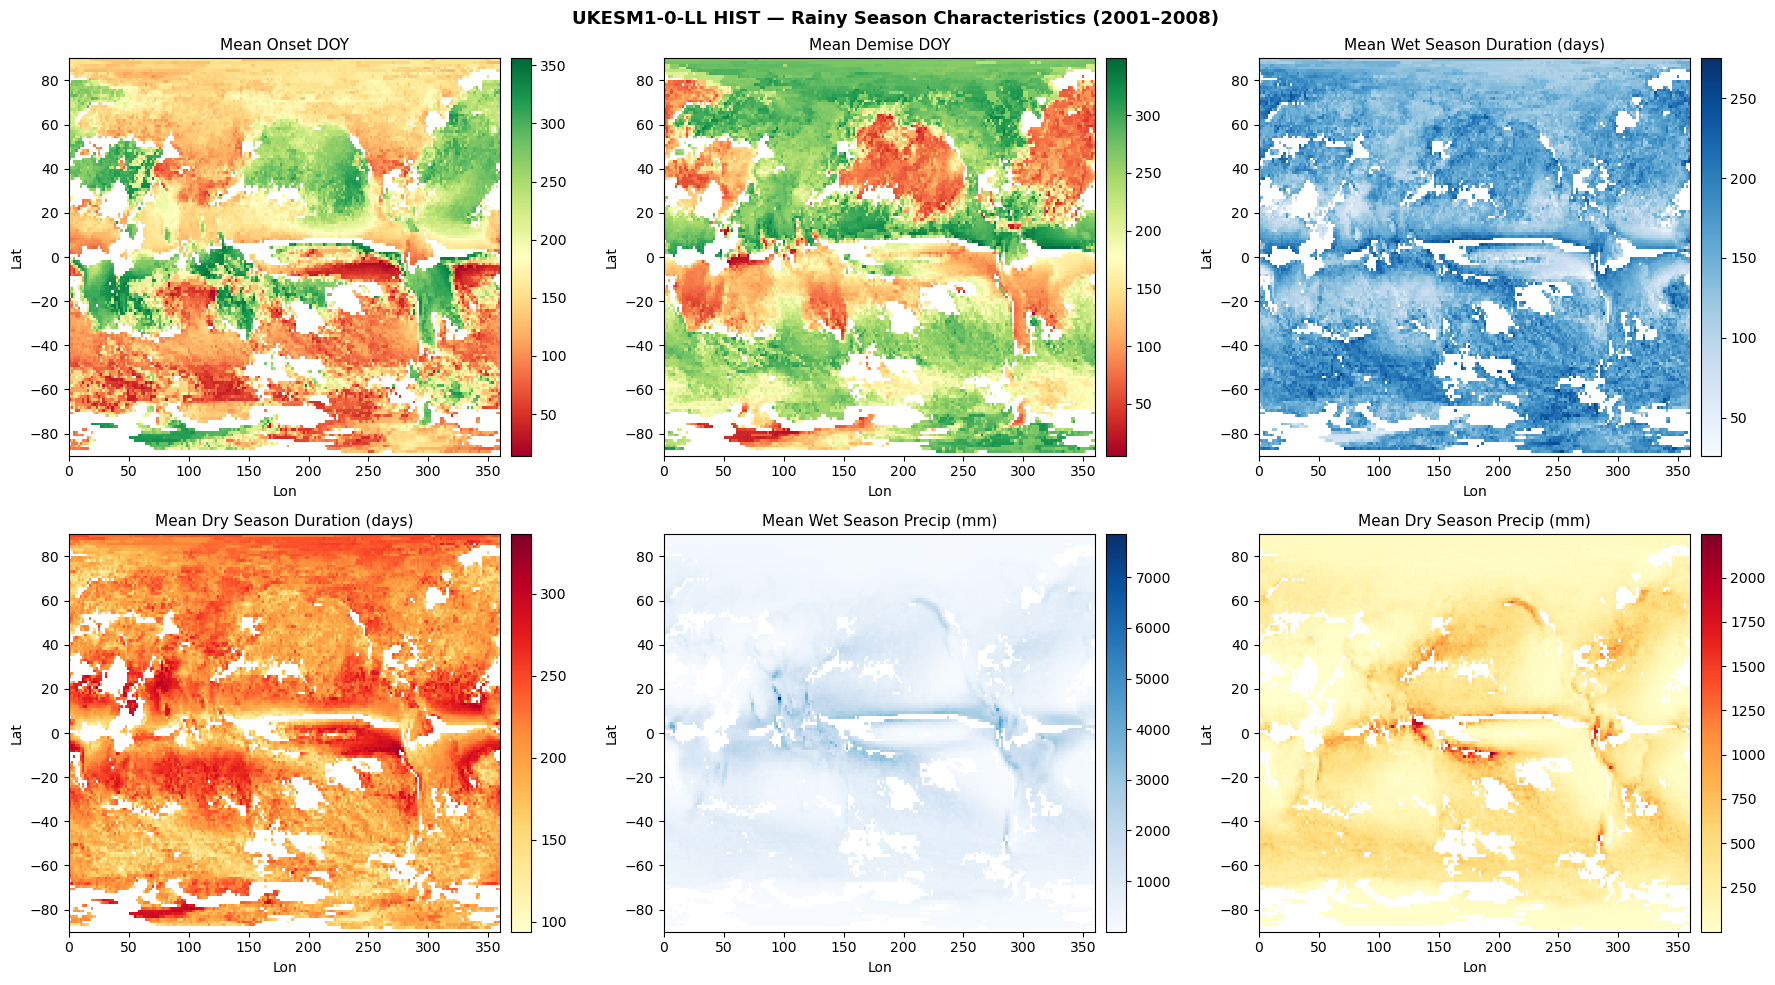

In [15]:
import matplotlib.pyplot as plt
import numpy as np

ds = ds_out

fig, axes = plt.subplots(2, 3, figsize=(18, 10),
                         subplot_kw={"projection": None})

variables = [
    ("onset_jday",  "Mean Onset DOY",              "RdYlGn"),
    ("demise_jday", "Mean Demise DOY",              "RdYlGn"),
    ("durwet",      "Mean Wet Season Duration (days)", "Blues"),
    ("durdry",      "Mean Dry Season Duration (days)", "YlOrRd"),
    ("totwet",      "Mean Wet Season Precip (mm)",   "Blues"),
    ("totdry",      "Mean Dry Season Precip (mm)",   "YlOrRd"),
]

for ax, (var, title, cmap) in zip(axes.flat, variables):
    data = ds[var].values.copy()
    data[data == missval] = np.nan          # mask missing
    mean_field = np.nanmean(data, axis=0)   # mean over years

    im = ax.pcolormesh(ds.lon, ds.lat, mean_field, cmap=cmap, shading="auto")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02)

plt.suptitle(f"{model_name} {exp} — Rainy Season Characteristics (2001–2008)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(out_dir / f"rainy_season_{model_name}_{exp}_summary.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Plot saved.")

/tmp/ipykernel_58515/2113896731.py:45: RuntimeWarning: Mean of empty slice
  mean_field = np.nanmean(data, axis=0)


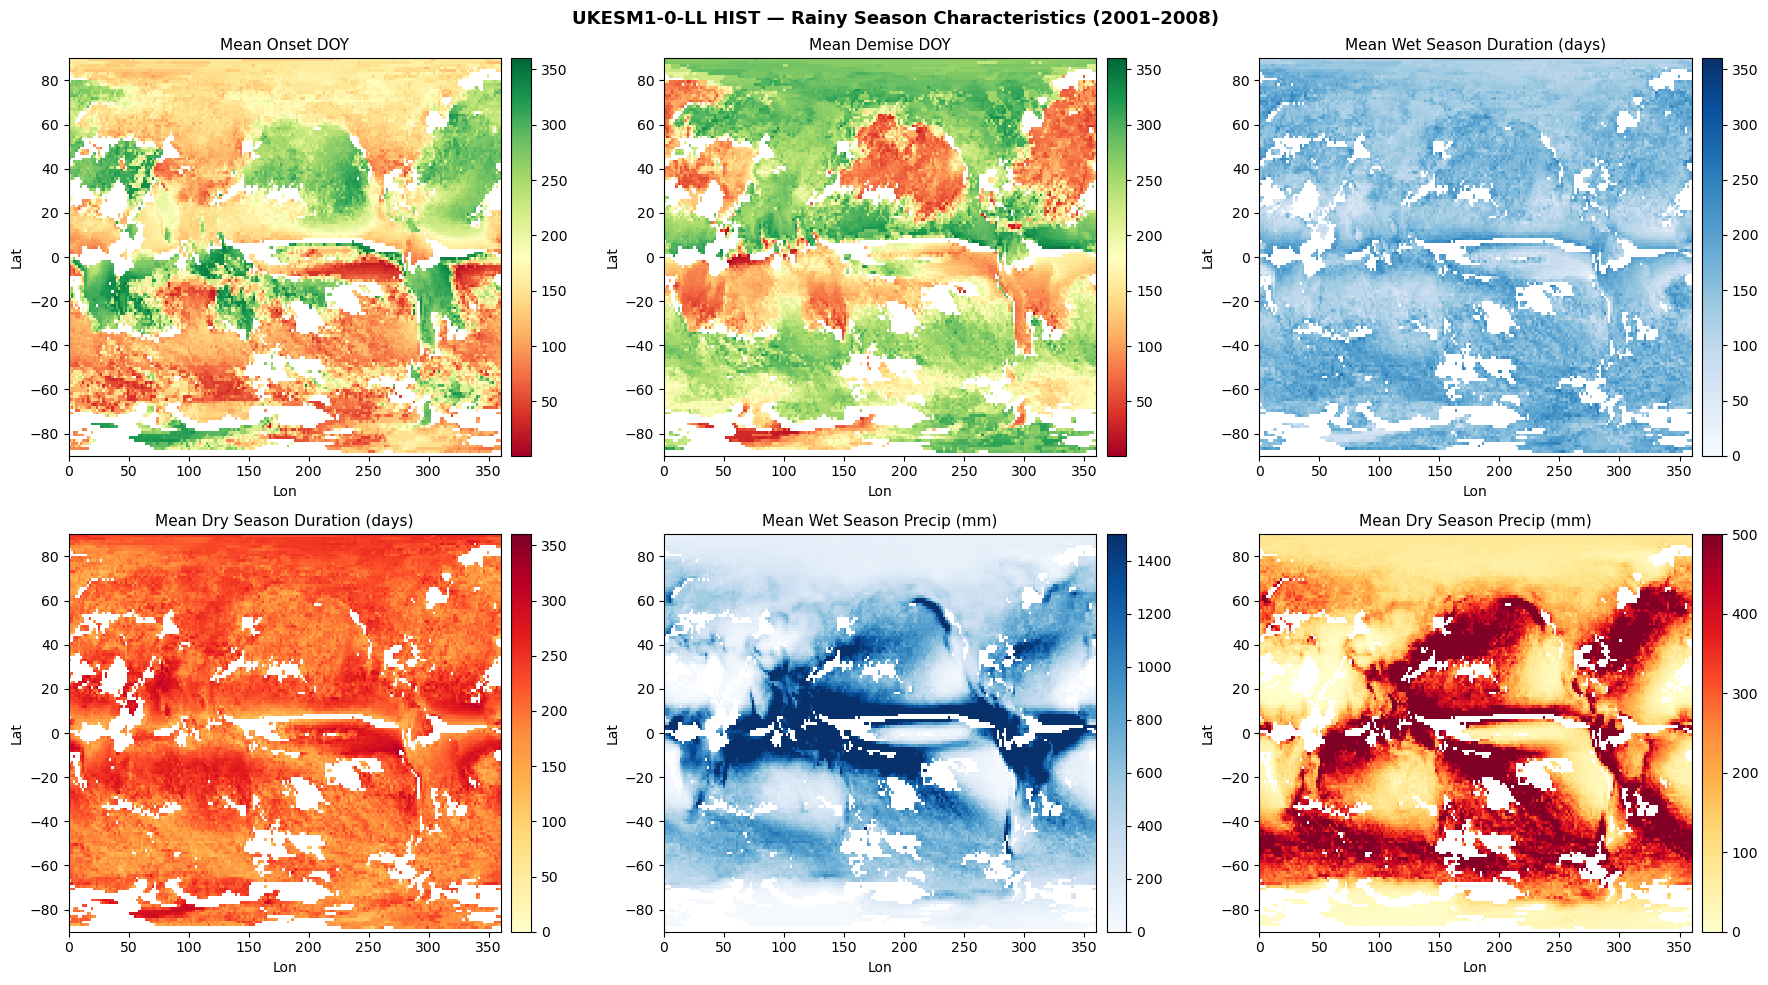

In [16]:
# Re-save with the cleaned arrays
ds_out.close() if hasattr(ds_out, 'close') else None

ds_out = xr.Dataset(
    {
        "onset_jday":   make_var(onset_jday,   "Wet season onset (Day of Year)",        "day_of_year"),
        "onset_day":    make_var(onset_day,    "Wet season onset (day of month)",        "1"),
        "onset_month":  make_var(onset_month,  "Wet season onset (month)",               "1"),
        "onset_year":   make_var(onset_year,   "Wet season onset (year)",                "1"),
        "demise_jday":  make_var(demise_jday,  "Wet season demise (Day of Year)",        "day_of_year"),
        "demise_day":   make_var(demise_day,   "Wet season demise (day of month)",       "1"),
        "demise_month": make_var(demise_month, "Wet season demise (month)",              "1"),
        "demise_year":  make_var(demise_year,  "Wet season demise (year)",               "1"),
        "totwet":       make_var(totwet,       "Accumulated precipitation (wet season)", "mm"),
        "totdry":       make_var(totdry,       "Accumulated precipitation (dry season)", "mm"),
        "durwet":       make_var(durwet,       "Duration of the wet season",             "days"),
        "durdry":       make_var(durdry,       "Duration of the dry season",             "days"),
    },
    coords=coords,
    attrs={
        "model":      model_name,
        "experiment": exp,
        "period":     f"{yr_start}-{yr_end}",
        "method":     "Bombardi et al. (2019) doi:10.1175/BAMS-D-18-0177.1",
    },
)
# ds_out.to_netcdf(outfile, encoding=encoding, mode="w")
# # print("Re-saved.")

# ── Replot from fresh ds_out ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

variables = [
    ("onset_jday",  "Mean Onset DOY",                  "RdYlGn",  1,    360),
    ("demise_jday", "Mean Demise DOY",                 "RdYlGn",  1,    360),
    ("durwet",      "Mean Wet Season Duration (days)", "Blues",   0,    360),
    ("durdry",      "Mean Dry Season Duration (days)", "YlOrRd",  0,    360),
    ("totwet",      "Mean Wet Season Precip (mm)",     "Blues",   0,   1500),
    ("totdry",      "Mean Dry Season Precip (mm)",     "YlOrRd",  0,    500),
]

for ax, (var, title, cmap, vmin, vmax) in zip(axes.flat, variables):
    data = ds_out[var].values.copy().astype(float)
    data[data == missval] = np.nan
    mean_field = np.nanmean(data, axis=0)
    im = ax.pcolormesh(ds_out.lon, ds_out.lat, mean_field,
                       cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    plt.colorbar(im, ax=ax, pad=0.02)

plt.suptitle(f"{model_name} {exp} — Rainy Season Characteristics (2001–2008)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(out_dir / f"rainy_season_{model_name}_{exp}_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()

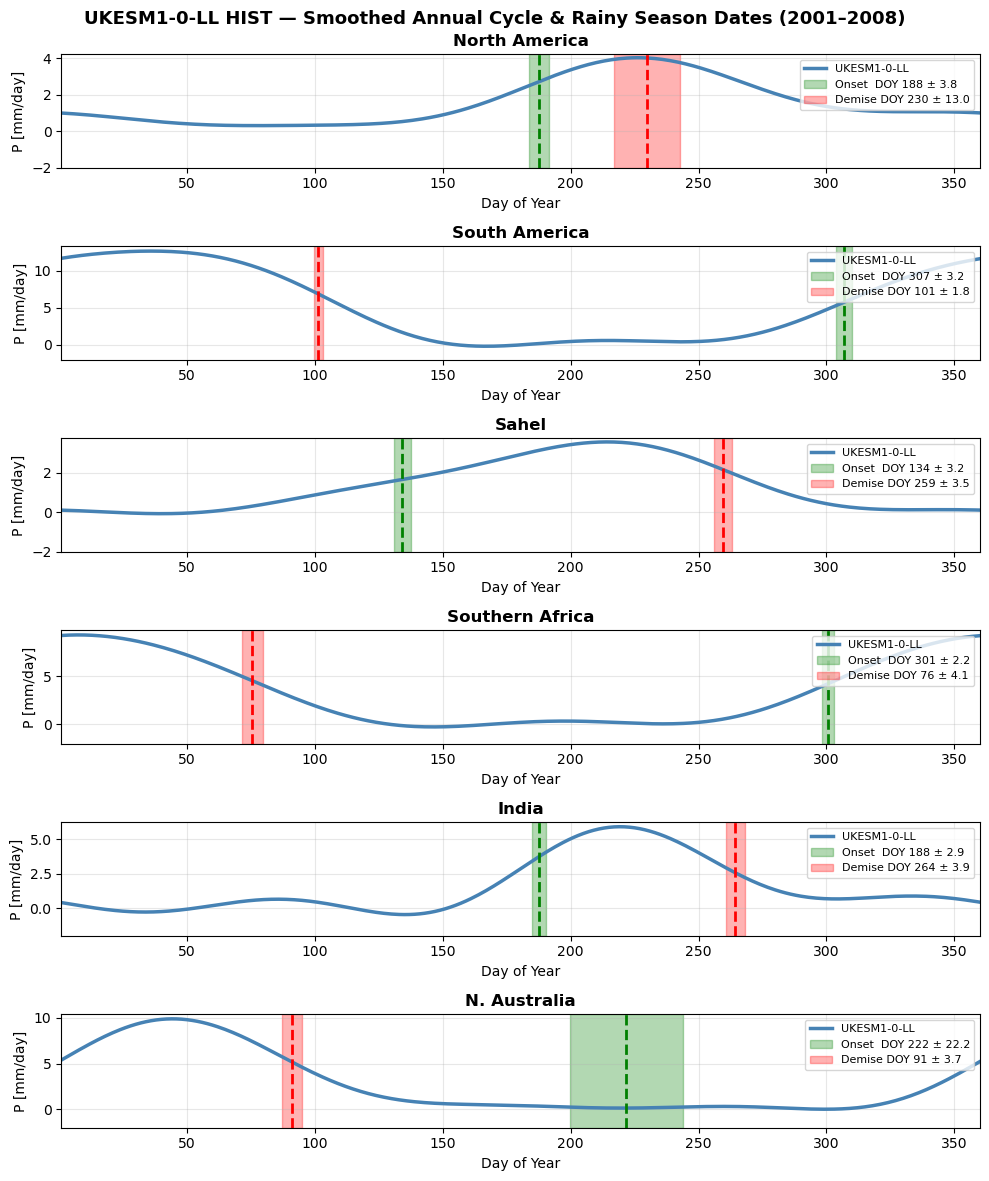

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ── Domain definitions ────────────────────────────────────────────────────────
domains = {
    "North America":    {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "South America":    {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Sahel":            {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "Southern Africa":  {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "India":            {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "N. Australia":     {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

# ── Build mean annual cycle from prec (shape: ntot, nlat, nlon) ───────────────
# prec is already in mm/day, shape (3600, 144, 192)

tot_int = int(tot)   # 360

fig, axes = plt.subplots(6, 1, figsize=(10, 12))

for ax, (region, dom) in zip(axes.flat, domains.items()):
    lat_min, lat_max = dom["lat"]
    lon_min, lon_max = dom["lon"]

    ilat = np.where((lats >= lat_min) & (lats <= lat_max))[0]
    ilon = np.where((lons >= lon_min) & (lons <= lon_max))[0]

    # ── Smoothed annual cycle ─────────────────────────────────────────────────
    smoothed_domain = smoothed[:, ilat, :][:, :, ilon].copy()
    mask_domain     = mask[ilat, :][:, ilon]
    smoothed_domain[:, mask_domain == 0.] = np.nan
    ann_cycle = np.nanmean(smoothed_domain, axis=(1, 2))
    # ann_cycle = np.clip(ann_cycle, 0, None)   # fix negatives

    # ── Onset/demise: mean per year first, then SE across years ──────────────
    onset_domain  = ds_out["onset_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
    demise_domain = ds_out["demise_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
    onset_domain[onset_domain   == missval] = np.nan
    demise_domain[demise_domain == missval] = np.nan

    # Mean over space per year → shape (nyrs-2,)
    onset_yearly  = np.nanmean(onset_domain,  axis=(1, 2))
    demise_yearly = np.nanmean(demise_domain, axis=(1, 2))

    # Mean and standard error across years
    n_onset  = np.sum(~np.isnan(onset_yearly))
    n_demise = np.sum(~np.isnan(demise_yearly))

    mean_onset  = np.nanmean(onset_yearly)
    mean_demise = np.nanmean(demise_yearly)
    se_onset    = np.nanstd(onset_yearly)  / np.sqrt(n_onset)   if n_onset  > 1 else 0
    se_demise   = np.nanstd(demise_yearly) / np.sqrt(n_demise)  if n_demise > 1 else 0

    # ── Plot ──────────────────────────────────────────────────────────────────
    doys = np.arange(1, tot_int + 1)

    ax.plot(doys, ann_cycle, color="steelblue", linewidth=2.5, label=f"{model_name}")
    # ax.fill_between(doys, ann_cycle, alpha=0.15, color="steelblue")
    # ax.axhline(0, color="black", linewidth=0.5)

    # Onset
    ax.axvline(mean_onset,  color="green", linewidth=2, linestyle="--")
    ax.axvspan(mean_onset  - se_onset,  mean_onset  + se_onset,
               alpha=0.3, color="green", label=f"Onset  DOY {mean_onset:.0f} ± {se_onset:.1f}")

    # Demise
    ax.axvline(mean_demise, color="red", linewidth=2, linestyle="--")
    ax.axvspan(mean_demise - se_demise, mean_demise + se_demise,
               alpha=0.3, color="red",   label=f"Demise DOY {mean_demise:.0f} ± {se_demise:.1f}")

    ax.set_title(region, fontsize=12, fontweight="bold")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("P [mm/day]")
    ax.set_xlim(1, tot_int)
    ax.set_ylim(bottom=-2)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

plt.suptitle(f"{model_name} {exp} — Smoothed Annual Cycle & Rainy Season Dates (2001–2008)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(out_dir / f"annual_cycle_smoothed_{model_name}_{exp}.png",
            dpi=150, bbox_inches="tight")
plt.show()

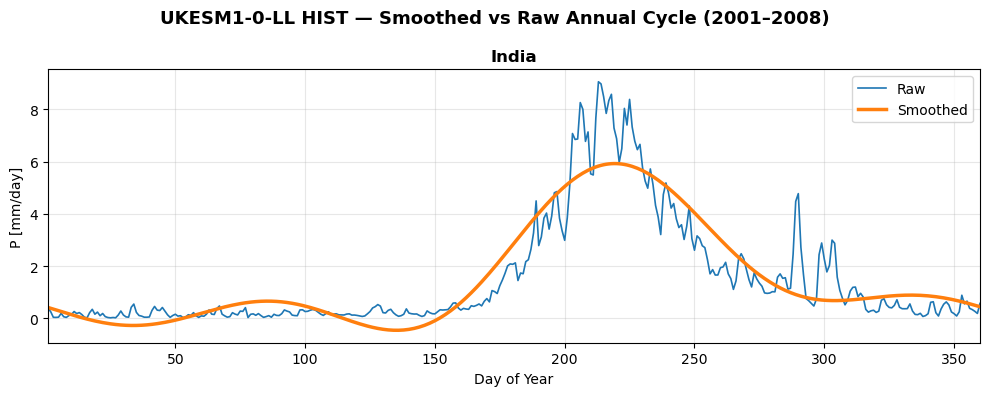

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ── Domain definitions ─────────────────────────────────────────────
domains = {
    "India": {"lat": (15.0, 27.0), "lon": (73.0, 87.0)},
}

tot_int = int(tot)   # should be 360
nyears = prec.shape[0] // tot_int   # should be 10

# Create as many subplots as domains
fig, axes = plt.subplots(len(domains), 1, figsize=(10, 4*len(domains)))

# Ensure axes is iterable if only one subplot
if len(domains) == 1:
    axes = [axes]

for ax, (region, dom) in zip(axes, domains.items()):
    
    lat_min, lat_max = dom["lat"]
    lon_min, lon_max = dom["lon"]

    ilat = np.where((lats >= lat_min) & (lats <= lat_max))[0]
    ilon = np.where((lons >= lon_min) & (lons <= lon_max))[0]

    mask_domain = mask[ilat][:, ilon]

    # ── Smoothed annual cycle ──────────────────────────────────────
    smoothed_domain = smoothed[:, ilat][:, :, ilon]
    smoothed_domain = np.where(mask_domain == 0, np.nan, smoothed_domain)
    ann_cycle = np.nanmean(smoothed_domain, axis=(1, 2))

    # ── Unsmoothed annual cycle (compute climatology properly) ─────────
    prec_domain = prec[:, ilat][:, :, ilon]
    prec_domain = np.where(mask_domain == 0, np.nan, prec_domain)
    
    # reshape to (nyears, 360, lat, lon)
    prec_domain = prec_domain.reshape(nyears, tot_int, len(ilat), len(ilon))
    
    # average over years, lat, lon
    ann_cycle_prec = np.nanmean(prec_domain, axis=(0, 2, 3))

    # ── Plot ───────────────────────────────────────────────────────
    doys = np.arange(1, tot_int + 1)

    ax.plot(doys, ann_cycle_prec, linewidth=1.2, label="Raw")
    ax.plot(doys, ann_cycle, linewidth=2.5, label="Smoothed")

    ax.set_title(region, fontsize=12, fontweight="bold")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("P [mm/day]")
    ax.set_xlim(1, tot_int)
    # ax.set_ylim(bottom=0)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

plt.suptitle(
    f"{model_name} {exp} — Smoothed vs Raw Annual Cycle (2001–2008)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [19]:
# fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# for ax, (region, dom) in zip(axes.flat, domains.items()):
#     lat_min, lat_max = dom["lat"]
#     lon_min, lon_max = dom["lon"]

#     ilat = np.where((lats >= lat_min) & (lats <= lat_max))[0]
#     ilon = np.where((lons >= lon_min) & (lons <= lon_max))[0]

#     # ── Smoothed annual cycle: average over domain ────────────────────────────
#     # smoothed shape: (tot_int, nlat, nlon)
#     smoothed_domain = smoothed[:, ilat, :][:, :, ilon]       # (360, nlat_d, nlon_d)
    
#     # Mask grid points that were masked out
#     mask_domain = mask[ilat, :][:, ilon]                      # (nlat_d, nlon_d)
#     smoothed_domain[:, mask_domain == 0.] = np.nan
    
#     ann_cycle_smoothed = np.nanmean(smoothed_domain, axis=(1, 2))   # (360,)

#     # ── Mean onset and demise DOY over the domain ─────────────────────────────
#     onset_domain  = ds_out["onset_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
#     demise_domain = ds_out["demise_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
#     onset_domain[onset_domain   == missval] = np.nan
#     demise_domain[demise_domain == missval] = np.nan

#     mean_onset  = np.nanmean(onset_domain)
#     mean_demise = np.nanmean(demise_domain)
#     std_onset   = np.nanstd(onset_domain)
#     std_demise  = np.nanstd(demise_domain)

#     # ── Plot ──────────────────────────────────────────────────────────────────
#     doys = np.arange(1, tot_int + 1)

#     ax.plot(doys, ann_cycle_smoothed, color="steelblue", linewidth=2.5)
#     ax.fill_between(doys, ann_cycle_smoothed, alpha=0.15, color="steelblue")

#     ax.axvline(mean_onset,  color="green", linewidth=2, linestyle="--",
#                label=f"Onset  DOY {mean_onset:.0f} ± {std_onset:.0f}")
#     ax.axvspan(mean_onset  - std_onset,  mean_onset  + std_onset,
#                alpha=0.15, color="green")

#     ax.axvline(mean_demise, color="red",   linewidth=2, linestyle="--",
#                label=f"Demise DOY {mean_demise:.0f} ± {std_demise:.0f}")
#     ax.axvspan(mean_demise - std_demise, mean_demise + std_demise,
#                alpha=0.15, color="red")

#     ax.set_title(region, fontsize=12, fontweight="bold")
#     ax.set_xlabel("Day of Year")
#     ax.set_ylabel("Precipitation (mm/day)")
#     ax.set_xlim(1, tot_int)
#     ax.set_ylim(bottom=0)
#     ax.legend(fontsize=9, loc="upper right")
#     ax.grid(True, alpha=0.3)

# plt.suptitle(f"{model_name} {exp} — Smoothed Annual Cycle & Rainy Season Dates (2001–2008)",
#              fontsize=13, fontweight="bold")
# plt.tight_layout()
# # plt.savefig(out_dir / f"annual_cycle_smoothed_{model_name}_{exp}.png",
# #             dpi=150, bbox_inches="tight")
# plt.show()
# print("Plot saved.")

In [20]:
# fig, axes = plt.subplots(6, 1, figsize=(10, 12))

# for ax, (region, dom) in zip(axes.flat, domains.items()):
#     lat_min, lat_max = dom["lat"]
#     lon_min, lon_max = dom["lon"]

#     ilat = np.where((lats >= lat_min) & (lats <= lat_max))[0]
#     ilon = np.where((lons >= lon_min) & (lons <= lon_max))[0]

#     # ── Smoothed annual cycle ─────────────────────────────────────────────────
#     smoothed_domain = smoothed[:, ilat, :][:, :, ilon].copy()
#     mask_domain     = mask[ilat, :][:, ilon]
#     smoothed_domain[:, mask_domain == 0.] = np.nan
#     ann_cycle = np.nanmean(smoothed_domain, axis=(1, 2))
#     # ann_cycle = np.clip(ann_cycle, 0, None)   # fix negatives

#     # ── Onset/demise: mean per year first, then SE across years ──────────────
#     onset_domain  = ds_out["onset_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
#     demise_domain = ds_out["demise_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
#     onset_domain[onset_domain   == missval] = np.nan
#     demise_domain[demise_domain == missval] = np.nan

#     # Mean over space per year → shape (nyrs-2,)
#     onset_yearly  = np.nanmean(onset_domain,  axis=(1, 2))
#     demise_yearly = np.nanmean(demise_domain, axis=(1, 2))

#     # Mean and standard error across years
#     n_onset  = np.sum(~np.isnan(onset_yearly))
#     n_demise = np.sum(~np.isnan(demise_yearly))

#     mean_onset  = np.nanmean(onset_yearly)
#     mean_demise = np.nanmean(demise_yearly)
#     se_onset    = np.nanstd(onset_yearly)  / np.sqrt(n_onset)   if n_onset  > 1 else 0
#     se_demise   = np.nanstd(demise_yearly) / np.sqrt(n_demise)  if n_demise > 1 else 0

#     # ── Plot ──────────────────────────────────────────────────────────────────
#     doys = np.arange(1, tot_int + 1)

#     ax.plot(doys, ann_cycle, color="steelblue", linewidth=2.5, label=f"{model_name}")
#     # ax.fill_between(doys, ann_cycle, alpha=0.15, color="steelblue")
#     # ax.axhline(0, color="black", linewidth=0.5)

#     # Onset
#     ax.axvline(mean_onset,  color="green", linewidth=2, linestyle="--")
#     ax.axvspan(mean_onset  - se_onset,  mean_onset  + se_onset,
#                alpha=0.3, color="green", label=f"Onset  DOY {mean_onset:.0f} ± {se_onset:.1f}")

#     # Demise
#     ax.axvline(mean_demise, color="red", linewidth=2, linestyle="--")
#     ax.axvspan(mean_demise - se_demise, mean_demise + se_demise,
#                alpha=0.3, color="red",   label=f"Demise DOY {mean_demise:.0f} ± {se_demise:.1f}")

#     ax.set_title(region, fontsize=12, fontweight="bold")
#     ax.set_xlabel("Day of Year")
#     ax.set_ylabel("P [mm/day]")
#     ax.set_xlim(1, tot_int)
#     ax.set_ylim(bottom=-2)
#     ax.legend(fontsize=8, loc="upper right")
#     ax.grid(True, alpha=0.3)

# plt.suptitle(f"{model_name} {exp} — Smoothed Annual Cycle & Rainy Season Dates (2001–2008)",
#              fontsize=13, fontweight="bold")
# plt.tight_layout()
# # plt.savefig(out_dir / f"annual_cycle_smoothed_{model_name}_{exp}.png",
# #             dpi=150, bbox_inches="tight")
# plt.show()

In [21]:
# If startwet still in memory from the HIST run:
ilat_au = np.where((lats >= -21.0) & (lats <= -9.5))[0]
ilon_au = np.where((lons >= 120.5) & (lons <= 149.0))[0]
sw = startwet[ilat_au, :][:, ilon_au]
sw[sw == 0] = np.nan
print(f"startwet N.Australia: min={np.nanmin(sw):.0f} max={np.nanmax(sw):.0f} mean={np.nanmean(sw):.0f}")

startwet N.Australia: min=205 max=251 mean=224
